# 03 — EDA: Customer-Level Features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RANDOM_SEED = 42
DATA_DIR = Path('..') / 'data' / 'raw'

pd.set_option('display.max_columns', 100)


## 1. Load Processed Data

In [2]:
PROCESSED_DIR = Path('..') / 'data' / 'processed'
customers = pd.read_csv(PROCESSED_DIR / 'customers.csv', index_col='customer_id')
customers['earliest_transaction_date'] = pd.to_datetime(customers['earliest_transaction_date'])
customers['latest_transaction_date']   = pd.to_datetime(customers['latest_transaction_date'])
print(customers.shape)
customers.head()


(49661, 29)


,earliest_transaction_date,latest_transaction_date,n_transactions,unique_product_categories,avg_amount_spent,std_amount_spent,total_returns,n_payment_methods_used,female,customer_age,churn,days_since_last_purchase,customer_tenure_days,return_rate,purchase_frequency,prct_paid_cash,prct_paid_credit_card,prct_paid_paypal,prct_txn_Books,prct_txn_Clothing,prct_txn_Electronics,prct_txn_Home,prct_spend_books,prct_spend_clothing,prct_spend_electronics,prct_spend_home,avg_days_between_transactions,std_days_between_transactions,spend_trend
customer_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,2020-03-04 10:26:02,2022-11-29 06:48:25,3,3,1866.666667,728.943299,0.0,2,1,67,0,288,999,0.000000,0.003003,0.333333,0.666667,0.00,0.333333,0.333333,0.333333,0.000000,0.407143,0.183036,0.409821,0.000000,499.500000,140.714249,635.000000
2,2020-07-31 16:27:41,2023-07-03 17:26:19,6,4,1076.500000,733.490763,4.0,3,1,42,0,72,1067,0.666667,0.005623,0.333333,0.166667,0.50,0.166667,0.166667,0.500000,0.166667,0.029416,0.113950,0.623781,0.232853,212.800000,118.480800,28.028571
3,2020-01-19 00:03:00,2023-02-03 03:58:07,4,3,903.250000,930.772931,0.0,3,0,31,0,222,1111,0.000000,0.003600,0.250000,0.500000,0.25,0.000000,0.250000,0.500000,0.250000,0.000000,0.039856,0.781622,0.178522,369.666667,243.643866,-558.900000
4,2020-10-12 22:03:10,2022-06-29 03:41:09,5,4,867.800000,673.754184,3.0,3,0,37,0,441,624,0.600000,0.008013,0.400000,0.200000,0.40,0.400000,0.200000,0.200000,0.200000,0.314358,0.377967,0.053238,0.254437,155.500000,51.630095,-64.300000
5,2020-04-08 21:57:19,2022-07-16 04:08:09,5,2,452.600000,314.805178,3.0,3,1,24,0,424,828,0.600000,0.006039,0.200000,0.400000,0.40,0.400000,0.000000,0.000000,0.600000,0.457357,0.000000,0.000000,0.542643,206.500000,165.098960,60.600000


## 2. Correlation Heatmap

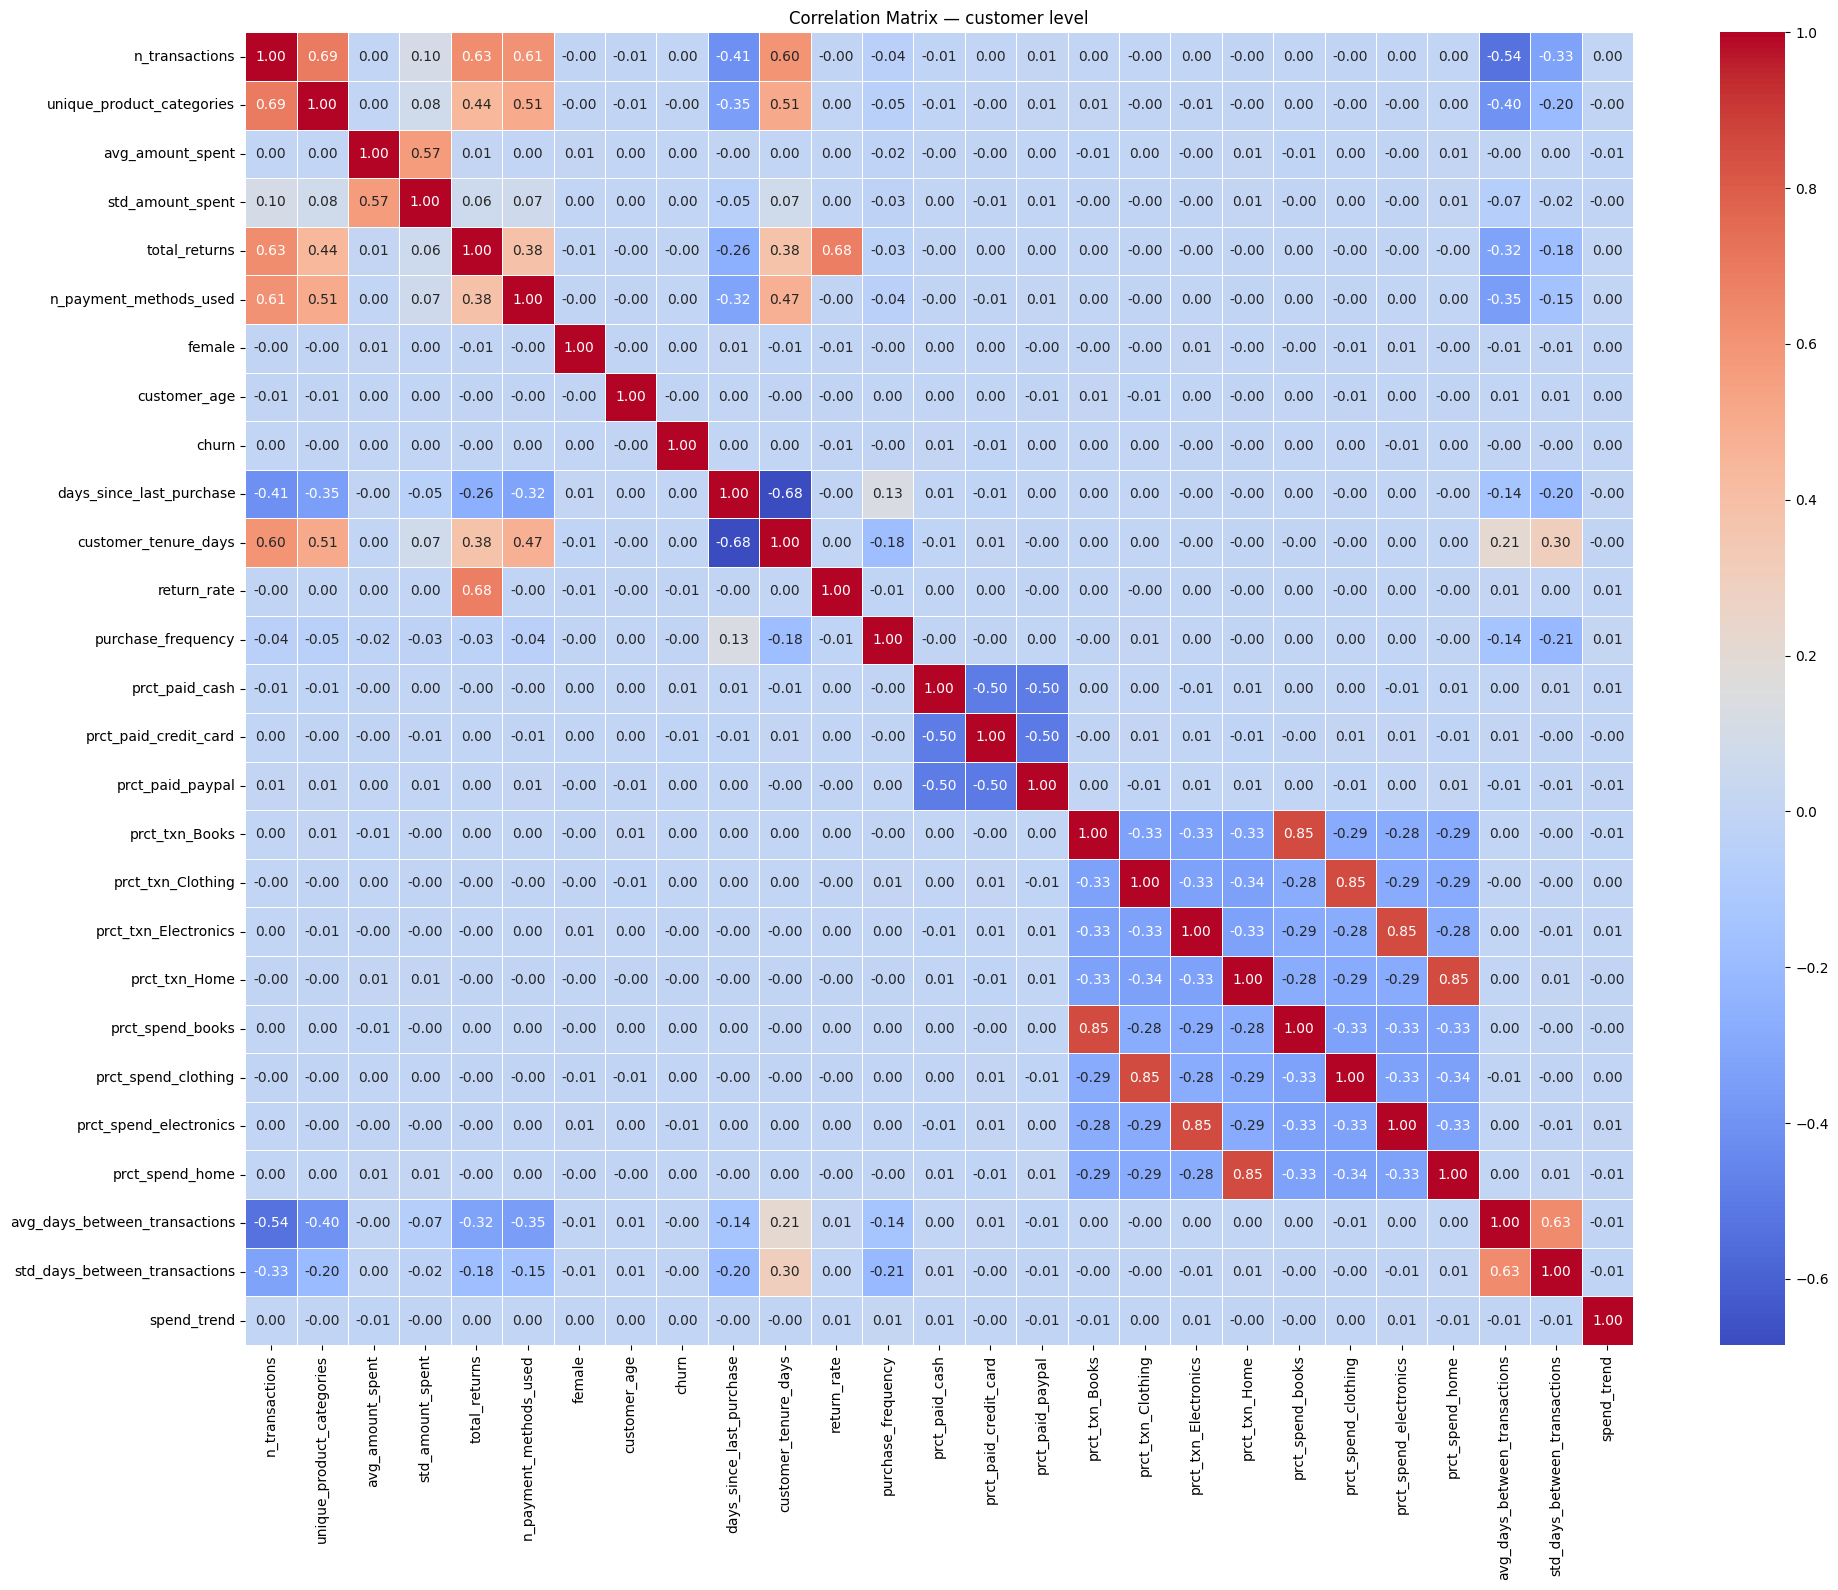

In [3]:
exclude_cols = ['earliest_transaction_date', 'latest_transaction_date']
cust_num = customers.drop(columns=exclude_cols).select_dtypes(include=np.number)

plt.figure(figsize=(20, 16))
sns.heatmap(cust_num.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix — customer level')
plt.tight_layout()
plt.show()


## 3. Feature Distributions vs Churn

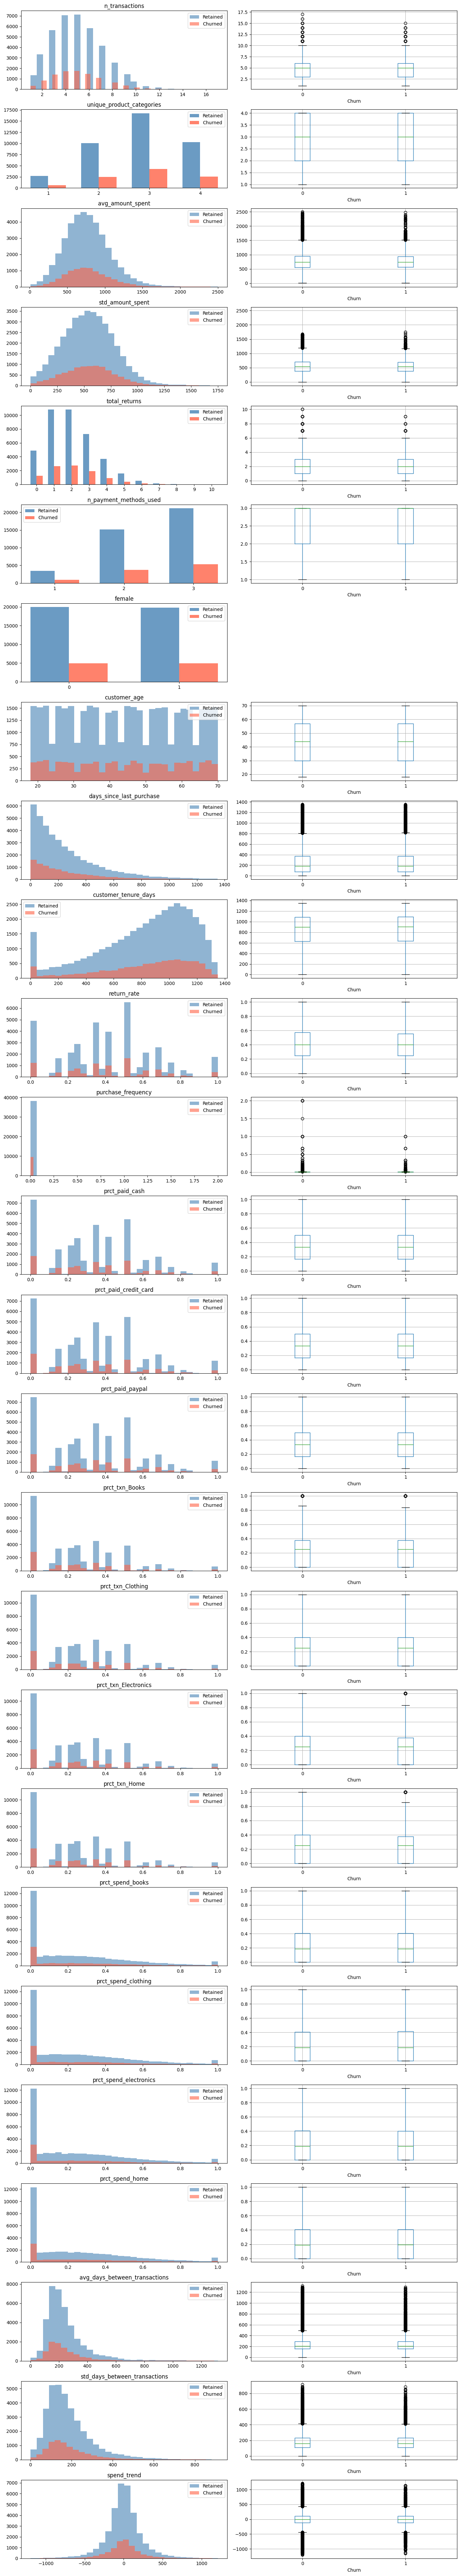

In [4]:
target_col    = 'churn'
exclude       = ['earliest_transaction_date', 'latest_transaction_date', target_col]
feat_cols     = [c for c in customers.columns if c not in exclude]

# Discrete columns — bar chart with integer x-axis, no continuous bins
DISCRETE_COLS = {'n_payment_methods_used', 'female', 'total_returns', 'unique_product_categories'}

# Binary columns — bar chart only, no boxplot
NO_BOXPLOT_COLS = {'female'}

# Columns whose boxplots share the same y-axis
SHARED_YAXIS = [['avg_amount_spent', 'std_amount_spent']]

def shared_ylim(cols):
    vals = customers[cols].values.flatten()
    vals = vals[~np.isnan(vals)]
    pad  = (vals.max() - vals.min()) * 0.05
    return vals.min() - pad, vals.max() + pad

shared_limits = {}
for group in SHARED_YAXIS:
    lim = shared_ylim(group)
    for c in group:
        shared_limits[c] = lim

fig, axes = plt.subplots(len(feat_cols), 2, figsize=(14, len(feat_cols) * 3))

for i, col in enumerate(feat_cols):
    ax_hist, ax_box = axes[i, 0], axes[i, 1]

    if col in DISCRETE_COLS:
        vals = sorted(customers[col].dropna().unique())
        x, w = np.arange(len(vals)), 0.35
        for j, (churn_val, label, color) in enumerate([(0,'Retained','steelblue'), (1,'Churned','tomato')]):
            counts = [customers[customers[target_col] == churn_val][col].value_counts().get(v, 0) for v in vals]
            ax_hist.bar(x + j * w, counts, width=w, label=label, color=color, alpha=0.8)
        ax_hist.set_xticks(x + w / 2)
        ax_hist.set_xticklabels([int(v) for v in vals])
    else:
        for churn_val, label, color in [(0,'Retained','steelblue'), (1,'Churned','tomato')]:
            subset = customers[customers[target_col] == churn_val][col].dropna()
            ax_hist.hist(subset, bins=30, alpha=0.6, label=label, color=color)

    ax_hist.set_title(col)
    ax_hist.legend()

    if col in NO_BOXPLOT_COLS:
        ax_box.set_visible(False)
    else:
        customers.boxplot(column=col, by=target_col, ax=ax_box)
        ax_box.set_title('')
        ax_box.set_xlabel('Churn')
        if col in shared_limits:
            ax_box.set_ylim(shared_limits[col])

plt.suptitle('')
plt.tight_layout()
plt.show()
